# **Exercises**

## Q1. The Stock market

In [1]:
import numpy as np
from numba import njit

In [2]:
states = ["bull", "bear", "stagnant"]
state_nums = np.array([0, 1, 2])
transition_matrix = np.array([[0.9,  0.075, 0.025], 
                              [0.15, 0.8,   0.05 ],
                              [0.25, 0.25,  0.5  ]])


# -------------------------------PURE PYTHON VERSION---------------------------------

def markov_chain(n_iterations):
    #set an initial choice
    market = np.random.randint(0,2,1)[0]
    market_states = [market]

    for i in range(n_iterations):
        transition =  np.random.choice(state_nums, 1, replace = False, p = transition_matrix[market])
        market = transition[0]
        market_states.append(market)
        i+=1

    return market_states


In [3]:
# -------------------------------------NUMBA VERSION---------------------------------
"""njit complains about random.choice so I will have to manually generate a number from 0 to 1 and
see in which interval it falls. That means this code is not really applicable to more complicated
markov chains, with more than 3 states, which would imply a larger transition matrix"""


@njit
def markov_chain_fast(n_iterations):
    #set an initial choice
    market = np.random.randint(0,2,1)[0]
    market_states = [market]

    for i in range(n_iterations):
        #get the array with the probability values of the transitions associated with the current market 
        prob_array = transition_matrix[market]
        #generate a random value between 0 and 1
        random_probability = np.random.random()

        """found a shady way to select the transition: basically, this line will return the indices of the
        prob_array that correspond to a probability smaller than the generated one. If there are no 
        elements in this array, its because the probability generated is larger than all the others.
        It's because we want to trasnition to the most likely scenario. If there is one, we still want to
        transition to the most likely state because it's a cumulative probability. If there are two elements
        we want to transition to the second most likely scenario. If there are three, the lowest probability 
        wins and we transition to the least likely state."""

        my_p_where = np.argwhere(random_probability<=prob_array)
        if np.logical_or(np.size(my_p_where)==0, np.size(my_p_where)==1):
            market =  np.argmax(prob_array)
        elif np.size(my_p_where)==3:
            market = np.argmin(prob_array)
        else:
           market = np.argwhere(np.logical_and(prob_array < np.max(prob_array), prob_array > np.min(prob_array)))[0][0]

        market_states.append(market)
        i+=1

    return market_states

In [4]:
days = 10000

%timeit markov_chain(days)
%timeit markov_chain_fast(days)

111 ms ± 3.56 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
1.96 ms ± 168 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)


We already saw if takes painfully longer to run it without python, but we can still actually run them to witnesss it.

In [5]:
print("\n\nMARKOV CHAIN IN PYTHON\n\n")

market_states = markov_chain(days)
print(f"After {days} days, the market, which started out in a " + states[market_states[0]] + " phase,",
"ended in a "+ states[market_states[-1]] + " phase. This was the flow:\n")

for i in range(days):
    print(states[market_states[i]], " -->", end = " ")
    if np.logical_and(i%9==0, i!=0):
        print("\n")
    if i == days-1:
        print(states[market_states[-1]])




MARKOV CHAIN IN PYTHON


After 10000 days, the market, which started out in a bear phase, ended in a bull phase. This was the flow:

bear  --> bull  --> bull  --> bull  --> bull  --> bull  --> bull  --> bull  --> bull  --> bull  --> 

bull  --> bull  --> bull  --> bull  --> bull  --> bull  --> stagnant  --> stagnant  --> stagnant  --> 

stagnant  --> stagnant  --> stagnant  --> stagnant  --> bull  --> bull  --> bull  --> bull  --> bull  --> 

bull  --> stagnant  --> stagnant  --> stagnant  --> stagnant  --> bear  --> bear  --> bear  --> bear  --> 

bear  --> bear  --> bear  --> bear  --> bear  --> bear  --> bear  --> bear  --> bear  --> 

bear  --> bear  --> bear  --> bear  --> bull  --> bull  --> bull  --> bull  --> bull  --> 

bear  --> bear  --> bull  --> bull  --> bull  --> bear  --> bear  --> bear  --> bear  --> 

bear  --> stagnant  --> bull  --> bull  --> bull  --> bull  --> bull  --> bull  --> bear  --> 

bear  --> bear  --> bear  --> bear  --> bear  --> bull  --> bull  --> b

In [6]:
print("\n\nMARKOV CHAIN IN PYTHON WITH NUMBA\n\n")

market_states = markov_chain_fast(days)

print(f"After {days} days, the market, which started out in a " + states[market_states[0]] + " phase,",
"ended in a "+ states[market_states[-1]] + " phase. This was the flow:\n")

for i in range(days):
    print(states[market_states[i]], " -->", end = " ")
    if np.logical_and(i%9==0, i!=0):
        print("\n")
    if i == days-1:
        print(states[market_states[-1]])



MARKOV CHAIN IN PYTHON WITH NUMBA


After 10000 days, the market, which started out in a bull phase, ended in a bull phase. This was the flow:

bull  --> bull  --> bull  --> bull  --> bull  --> bull  --> bull  --> bull  --> bull  --> bull  --> 

bull  --> bull  --> bear  --> bear  --> bear  --> bear  --> bull  --> bull  --> bull  --> 

bull  --> bull  --> bull  --> bull  --> bull  --> bull  --> bull  --> bull  --> bull  --> 

bull  --> bull  --> bull  --> bull  --> bull  --> bull  --> bull  --> bull  --> bull  --> 

bull  --> bull  --> bull  --> bull  --> bull  --> bull  --> bull  --> bull  --> bull  --> 

bull  --> bull  --> bull  --> bull  --> bull  --> bull  --> bull  --> bull  --> bull  --> 

bull  --> bull  --> bull  --> bull  --> bull  --> bull  --> bull  --> bull  --> bull  --> 

bear  --> bear  --> bear  --> stagnant  --> bull  --> bull  --> bull  --> bull  --> bull  --> 

bull  --> bull  --> bull  --> bull  --> bull  --> bull  --> bull  --> bull  --> bull  --> 

bull  --> bu

## Q2. Consistent plotting

In [7]:
import matplotlib.pyplot as plt

In [8]:
def plotting():

    x_ars = np.array([np.linspace(0,2*np.pi, 100), 
                     np.linspace(0,2*np.pi, 100),
                     np.linspace(0,2*np.pi, 100)]) 
    #2D array, each row is an x array for a plot
    y_ars = np.array([np.cos(x_ars[0,:]),
                      np.sin(x_ars[1,:]),
                      np.cos(2*x_ars[0,:])]) 
    #2D array, each row is a y array for a plot
    colors = ["blue", "pink", "green"] 
    #color of each plot - list of strings, 
    #the size should be the number of rows of x_ars and y_ars
    labels = [r"$y_1 = \cos(x)$", r"$y_2 = \sin(x)$",r"$y_3 = \cos(2x)$"] 
    #label for each line we plot - list of strings
    title = r"My beautiful plot"
    #title on the top of the figure - string
    xlabel = r"$x$ (rad)"
    #label of the x axis - string
    ylabel = r"$y(x)$"
    #label of the y axis - string

    my_figure = plt.figure(figsize = (6,6))
    my_figure.suptitle(title, fontsize = 12)
    ax = plt.subplot(111)

    for i in range(np.size(x_ars[:,0])):
        ax.plot(x_ars[i], y_ars[i], color = colors[i], linewidth = 1.1, label = labels[i] )

    ax.legend(loc = "best", fontsize = 9)
    ax.set_xlabel(xlabel, fontsize = 10)
    ax.set_ylabel(ylabel, fontsize = 10)

    return my_figure

In [9]:
def my_plot(func):

    def wrapper():
        plt.style.use("fivethirtyeight")
        plt.rcParams.update({
        "text.usetex": True,
        "font.family": "Courier"})
    
        res = input('are you sure you want to plot? [y/n]')
        if res=='n':
            return
        elif res=='y':
            func_return = func()
        func_return.savefig("out_dir/L07_my_beautiful_plot.pdf")
        return 0
    
    return wrapper
        

0

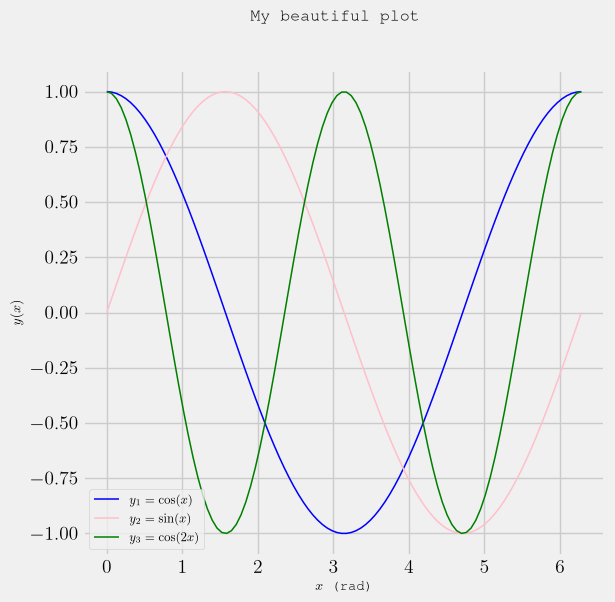

In [10]:
mynewplot = my_plot(plotting)
mynewplot()